In [1]:
# Intelligent Ticket Prioritization using Machine Learning
# This project predicts the priority level (High / Medium / Low) of support tickets
# using Natural Language Processing and classification models.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import nltk

from nltk.corpus import stopwords

In [3]:
df = pd.read_csv("DATASET.csv")
df.head(10)

,Ticket_ID,Customer_Name,Customer_Email,Ticket_Subject,Ticket_Description,Issue_Category,Priority_Level,Ticket_Channel,Submission_Date,Resolution_Time_Hours,Assigned_Agent,Satisfaction_Score
0,TKT-110650,Crystal Bennett,Eric.Pruitt@tech.io,Change email - Trial,"Hi Support, I lost my phone and cannot pass th...",Account,Low,Web Form,2025-02-09,5,David Kim,4
1,TKT-102041,Hannah Davis,elizabethbrown@example.org,API Error 500 - Style,"Hi Support, We are receiving a 500 Internal Se...",Technical,Low,Email,2024-05-03,11,Chloe Adams,4
2,TKT-108668,Dr. Melinda Peck,waltersronald@example.org,Login failed - Speak,"Hi Support, The application crashes every time...",Technical,Low,Email,2025-08-16,4,Elena Rodriguez,4
3,TKT-101114,Calvin Bryan,rroman@example.org,Payment failed - Them,"Hi Support, I requested a refund 5 days ago, w...",Billing,Low,Email,2024-08-01,16,David Kim,1
4,TKT-113902,Victoria Marsh,David.Aguirre@tech.io,Login failed - Learn,"Hi Support, My data hasn't synced to the cloud...",Technical,Low,Web Form,2025-11-10,120,Ben Carter,5
5,TKT-111963,Martha Fowler,kingsean@example.org,Refund status - Strong,"Hi Support, I have been trying to update my pa...",Billing,Low,Web Form,2024-10-08,19,Elena Rodriguez,5
6,TKT-111072,Samuel Lee,thomasferguson@example.net,App crashing - Computer,"Hi Support, The application crashes every time...",Technical,Low,Chat,2025-12-11,35,Anya Sharma,5
7,TKT-103002,Barbara Flores,Kathleen.Richardson@company.com,Update credit card - Own,"Hi Support, Why is my bill higher than the agr...",Billing,Low,Web Form,2025-09-13,120,Ben Carter,5
8,TKT-119771,Maria Fleming,jeffreyrichards@example.com,Data not syncing - Travel,"Hi Support, The dashboard is not loading any d...",Technical,Critical,Web Form,2025-09-03,11,David Kim,4
9,TKT-108115,John Miller,Sandra.Meyer@tech.io,Screen freezes - South,"Hi Support, We are receiving a 500 Internal Se...",Technical,Medium,Chat,2025-10-26,9,Ben Carter,5


In [4]:
print("Shape of dataset:", df.shape)
print("\nColumns:\n", df.columns)

print("\nPriority Distribution:")
print(df["Priority_Level"].value_counts())

Shape of dataset: (10000, 12)

Columns:
 Index(['Ticket_ID', 'Customer_Name', 'Customer_Email', 'Ticket_Subject',
       'Ticket_Description', 'Issue_Category', 'Priority_Level',
       'Ticket_Channel', 'Submission_Date', 'Resolution_Time_Hours',
       'Assigned_Agent', 'Satisfaction_Score'],
      dtype='object')

Priority Distribution:
Priority_Level
Low         3892
Medium      3753
High        1683
Critical     672
Name: count, dtype: int64


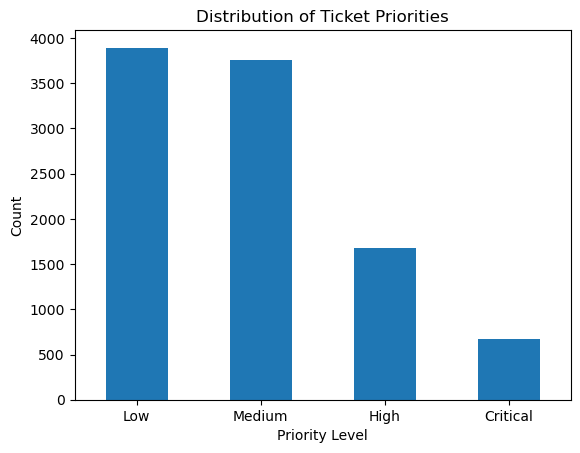

In [5]:
df["Priority_Level"].value_counts().plot(
    kind='bar',
    title="Distribution of Ticket Priorities"
)

plt.xlabel("Priority Level")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

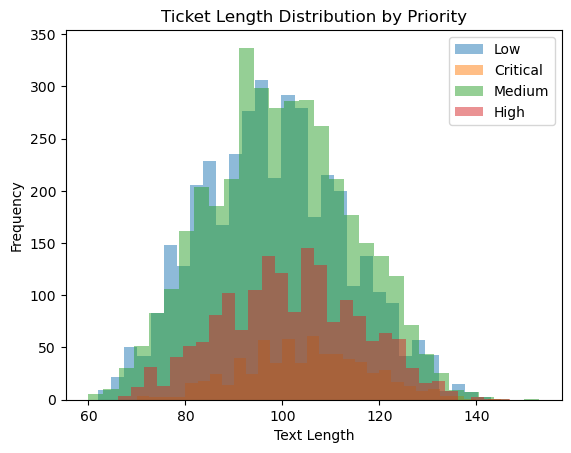

In [6]:
# Create a new feature: length of ticket
df["Text_Length"] = df["Ticket_Description"].astype(str).apply(len)

plt.figure()
for label in df["Priority_Level"].unique():
    subset = df[df["Priority_Level"] == label]
    plt.hist(subset["Text_Length"], bins=30, alpha=0.5, label=label)

plt.title("Ticket Length Distribution by Priority")
plt.xlabel("Text Length")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [7]:
#NLP

In [8]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\noopu\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [9]:
#clean text
def clean_text(text):
    text = str(text).lower()                  # convert to lowercase
    text = re.sub(r'[^a-zA-Z]', ' ', text)    # remove numbers/symbols
    words = text.split()                      # split into words
    words = [w for w in words if w not in stop_words]  # remove stopwords
    return " ".join(words)

In [10]:
#cleaning
df["Ticket_Description"] = df["Ticket_Description"].apply(clean_text)
df["Ticket_Subject"] = df["Ticket_Subject"].apply(clean_text)

In [11]:
#combine texr
df["Full_Text"] = df["Ticket_Subject"] + " " + df["Ticket_Description"]

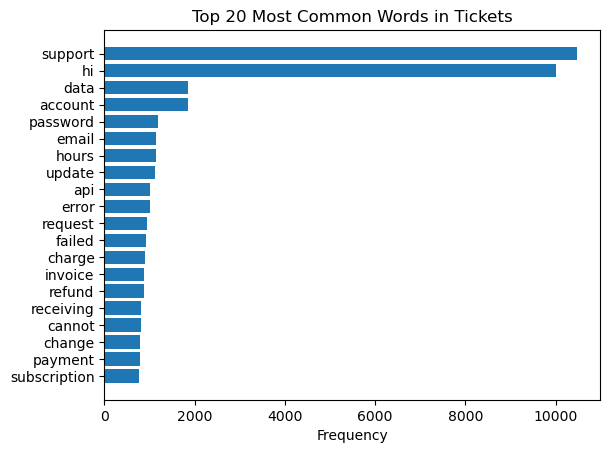

In [12]:
#most common words
from collections import Counter

all_words = " ".join(df["Full_Text"]).split()
common_words = Counter(all_words).most_common(20)

words = [w[0] for w in common_words]
counts = [w[1] for w in common_words]

plt.figure()
plt.barh(words, counts)
plt.title("Top 20 Most Common Words in Tickets")
plt.xlabel("Frequency")
plt.gca().invert_yaxis()
plt.show()

In [13]:
#feature engineering & models

In [14]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(df["Priority_Level"])

In [15]:
#TF IDF(text into numerical features based on word importance)
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df["Full_Text"])

In [16]:
print("Shape of feature matrix:", X.shape)

Shape of feature matrix: (10000, 975)


In [17]:
#test train split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [18]:
#defining models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

In [19]:
from sklearn.metrics import classification_report

for name, model in models.items():
    print(f"\n{name}")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(classification_report(y_test, y_pred))


Logistic Regression
              precision    recall  f1-score   support

           0       0.63      0.47      0.54       127
           1       0.28      0.13      0.17       351
           2       0.48      0.55      0.52       781
           3       0.40      0.46      0.43       741

    accuracy                           0.44      2000
   macro avg       0.45      0.40      0.41      2000
weighted avg       0.43      0.44      0.42      2000


Decision Tree
              precision    recall  f1-score   support

           0       0.48      0.45      0.46       127
           1       0.22      0.16      0.18       351
           2       0.46      0.47      0.46       781
           3       0.40      0.44      0.42       741

    accuracy                           0.40      2000
   macro avg       0.39      0.38      0.38      2000
weighted avg       0.39      0.40      0.40      2000


Random Forest
              precision    recall  f1-score   support

           0       0.61 

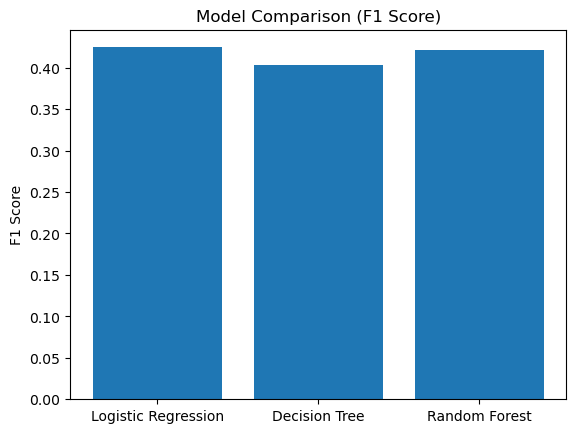

In [20]:
f1_scores = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    report = classification_report(y_test, y_pred, output_dict=True)
    f1_scores.append(report["weighted avg"]["f1-score"])

plt.figure()
plt.bar(models.keys(), f1_scores)
plt.title("Model Comparison (F1 Score)")
plt.ylabel("F1 Score")
plt.show()

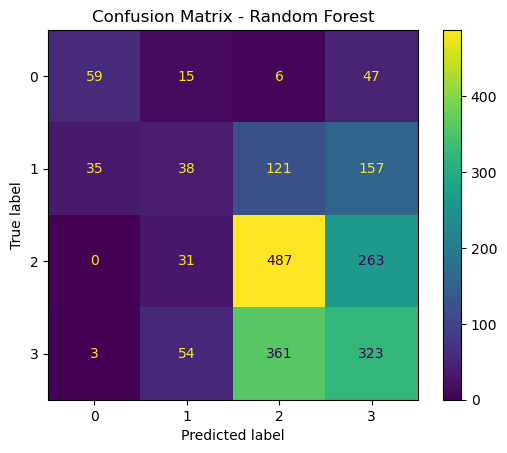

In [21]:
#confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

#  Random Forest best model 
model = RandomForestClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix - Random Forest")
plt.show()

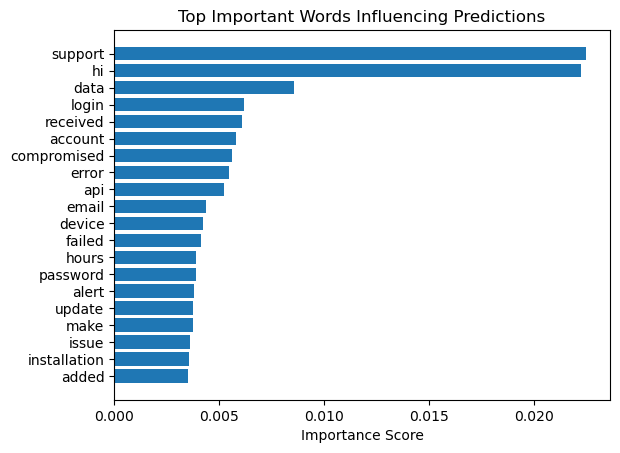

In [26]:
import numpy as np

feature_names = vectorizer.get_feature_names_out()
importances = model.feature_importances_

indices = np.argsort(importances)[-20:]

plt.figure()
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])

plt.title("Top Important Words Influencing Predictions")
plt.xlabel("Importance Score")
plt.show()

In [32]:
sample = ["how to reset password"]

sample_vec = vectorizer.transform(sample)

prediction = model.predict(sample_vec)

predicted_label = le.inverse_transform(prediction)

print("Predicted Priority:", predicted_label[0])

Predicted Priority: Low
